In [4]:
# Local environment check
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [5]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Setup complete  (8 CPUs, 7.9 GB RAM, 288.9/475.7 GB disk)


In [6]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow
load_dotenv()
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("emilija").project("robot-arm-pose-sz7o3-etkuy")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [7]:
from ultralytics import YOLO
print(dataset)
model = YOLO("yolov8n-pose.pt") 
model.train(data=f"{dataset.location}/data.yaml", epochs=100, imgsz=640, batch=8, device=0, degrees=10, scale=0.15, translate=0.1, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, rect=False, cache=True)


Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000018B13431D60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,

c:\Users\Abcd1\Robot-arm-keypoint-detection


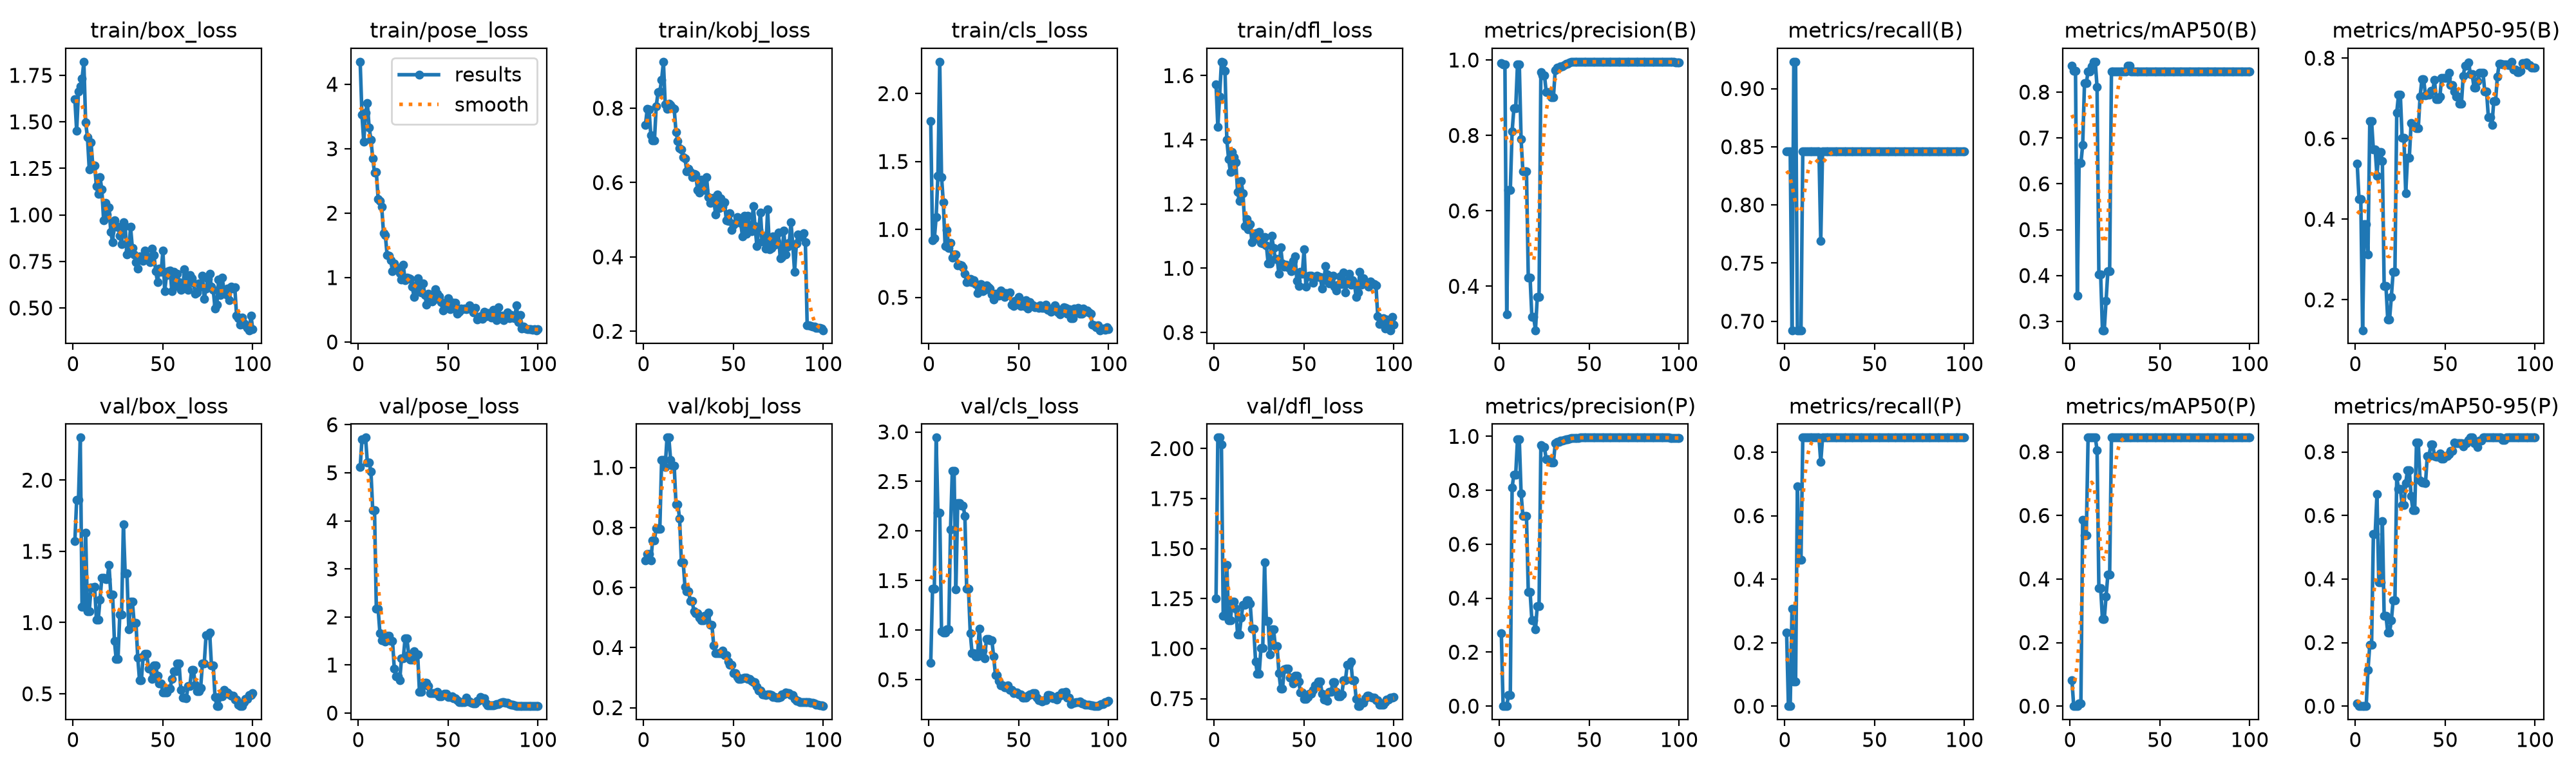

In [9]:
from IPython.display import Image
import os
HOME=os.getcwd()
print(HOME)
Image(filename=f'{HOME}/runs/pose/train/results.png', width=2000)

In [7]:
#Image(filename=f'{HOME}/runs/pose/train/confusion_matrix.png', width=1200)

In [11]:
#validation
model = YOLO(f"{HOME}/runs/pose/train/weights/best.pt")

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split="val"
)

Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLOv8n-pose summary (fused): 81 layers, 3,078,128 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 233.131.8 MB/s, size: 214.2 KB)
val: Scanning C:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\valid\labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all         11         13      0.995      0.846      0.845      0.791      0.995      0.846      0.845      0.845
Speed: 0.6ms preprocess, 5.5ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to C:\Users\Abcd1\Robot-arm-keypoint-detection\runs\pose\val


In [13]:
#inference
from ultralytics import YOLO

model = YOLO(f"{HOME}/runs/pose/train/weights/best.pt")

results = model.predict(
    source=f"{dataset.location}/test/images",
    save=True,
    conf=0.25
) 


image 1/5 c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_00025_jpg.rf.dac66b7b0b7b38340214ecafc7e038c4.jpg: 384x640 1 robotarm, 42.3ms
image 2/5 c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_00863_jpg.rf.4e14e2d2abe9826f1a1a8f2d8d9c6fcf.jpg: 384x640 1 robotarm, 63.1ms
image 3/5 c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01006_jpg.rf.3a65fb8f167cea0e118f4fc1ae0f7252.jpg: 384x640 1 robotarm, 70.9ms
image 4/5 c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01011_jpg.rf.c668c495c7f9d1118e64139506cdc1c6.jpg: 384x640 1 robotarm, 54.5ms
image 5/5 c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01277_jpg.rf.17176f80d6516391b58b9950dd6662d0.jpg: 384x640 1 robotarm, 58.4ms
Speed: 6.1ms preprocess, 57.8ms inference, 6.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\Abcd1\Robot-arm-keypoint-detection\runs\pose\p

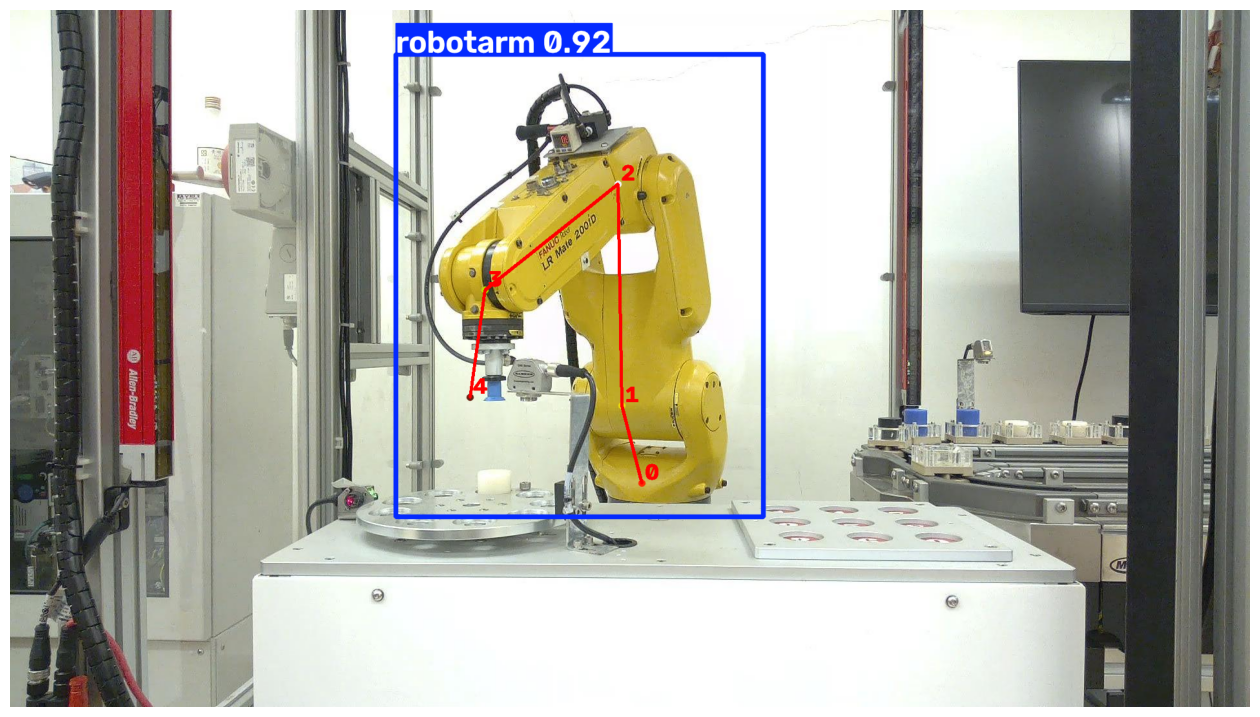

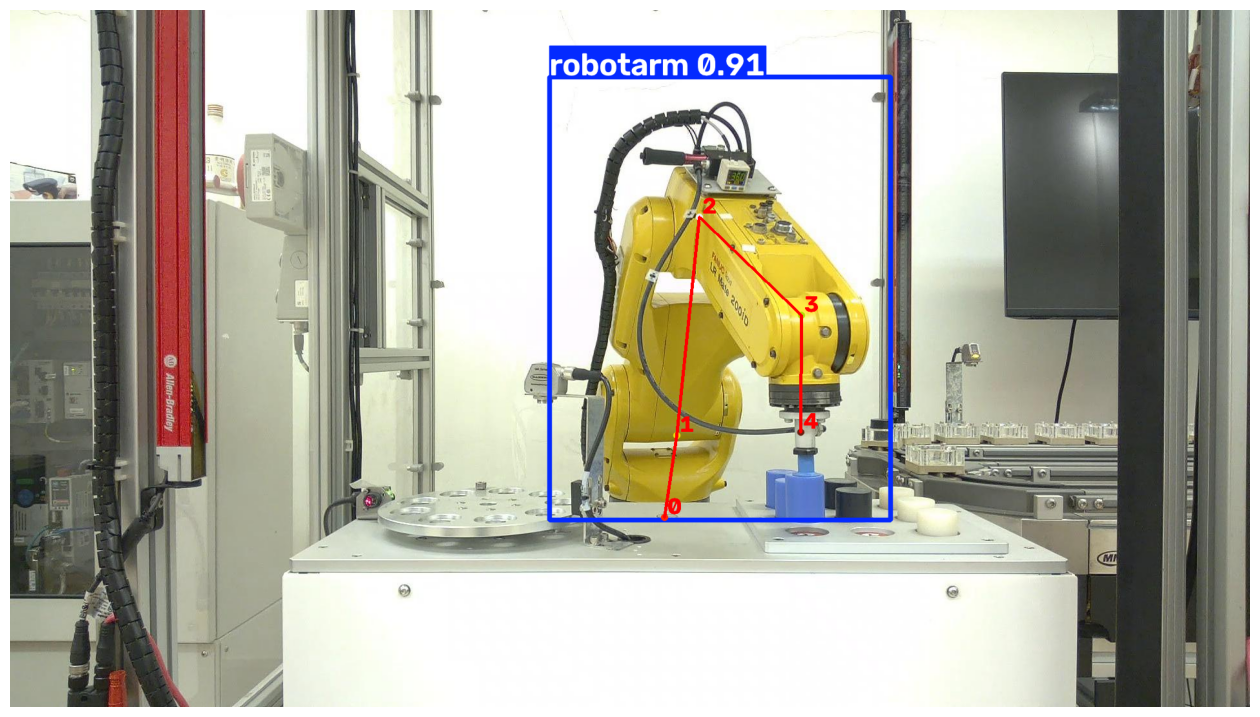

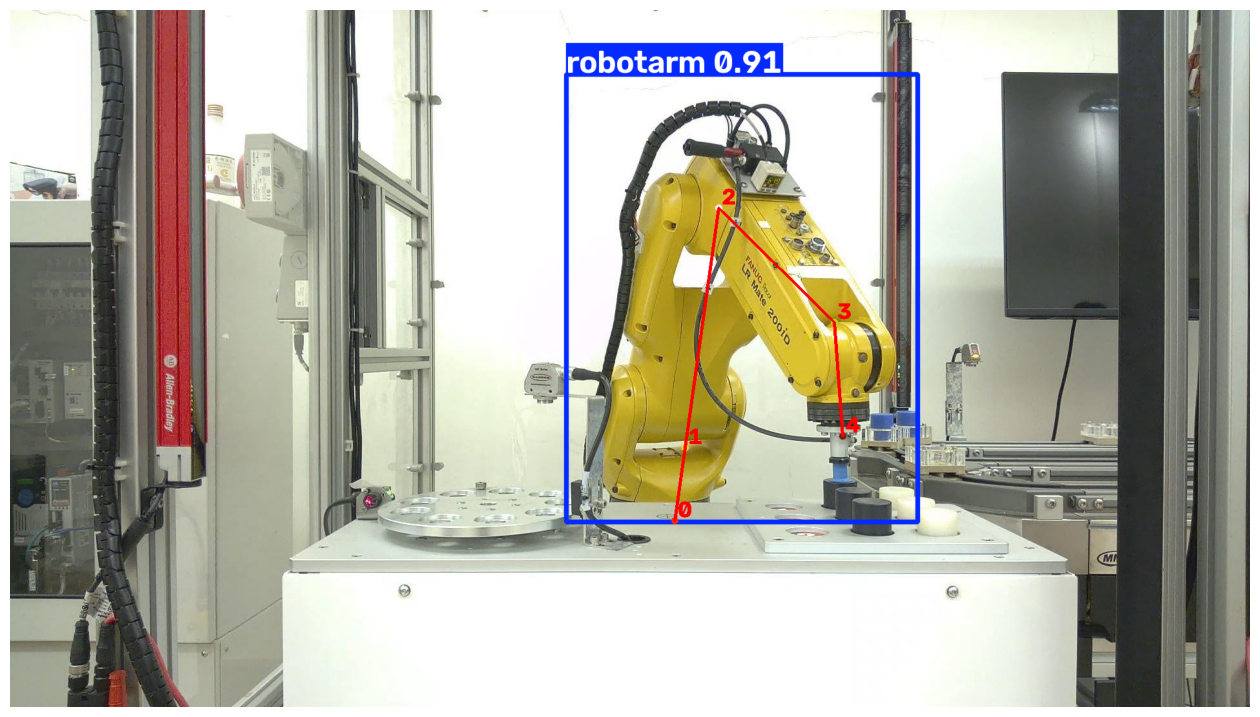

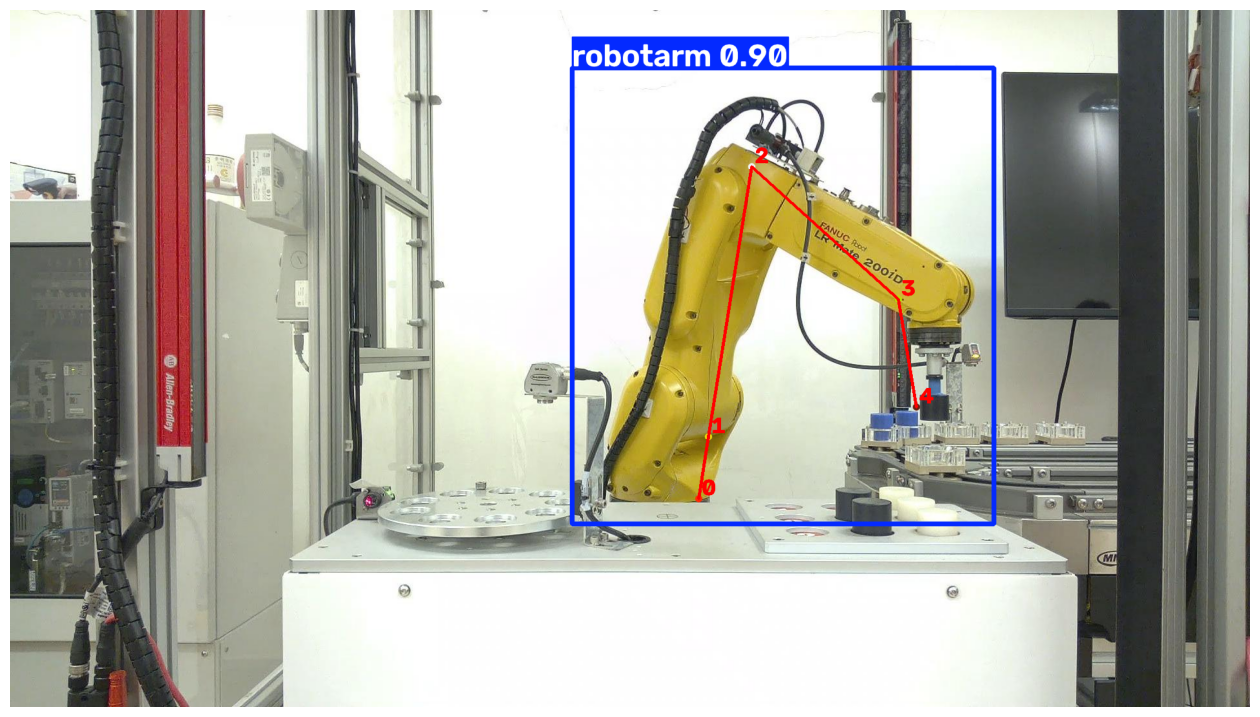

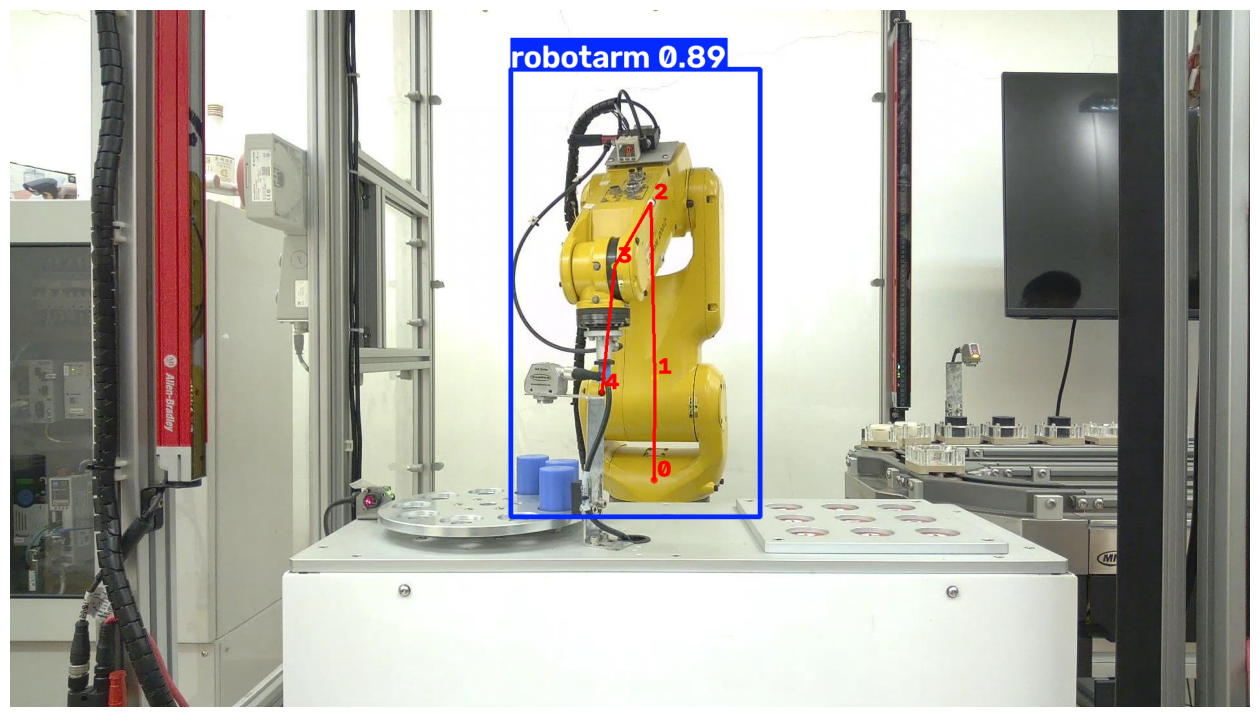

In [14]:
import glob
from IPython.display import Image, display

"""for image_path in glob.glob(f'{HOME}/runs/pose/predict-4/*.jpg'):
      display(Image(filename=image_path, height=600))
      print("\n")"""

import cv2
import matplotlib.pyplot as plt
for r in results:
    img = r.plot()  # YOLO draws skeleton and keypoints
    if r.keypoints is not None:
        pts = r.keypoints.xy[0].cpu().numpy()
        for arm in pts:   # one robot arm
            for idx, (x, y) in enumerate(pts):
                cv2.putText(img, str(idx),(int(x) + 5, int(y) - 5), #5px right, 5px up
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
        for i in range(len(pts) - 1):
            x1, y1 = pts[i]
            x2, y2 = pts[i + 1]
            cv2.line(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 3)

    plt.figure(figsize=(16, 16))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [15]:
with open(f"{dataset.location}/data.yaml", "r") as f:
    print(f.read())


flip_idx:
- 0
- 1
- 2
- 3
- 4
kpt_shape:
- 5
- 3
names:
- robotarm
nc: 1
roboflow:
  license: CC BY 4.0
  project: robot-arm-pose-sz7o3-etkuy
  url: https://universe.roboflow.com/emilija/robot-arm-pose-sz7o3-etkuy/dataset/1
  version: 1
  workspace: emilija
test: ../test/images
train: ../train/images
val: ../valid/images



In [16]:
import os
for root, dirs, files in os.walk(dataset.location):
    for f in files:
        print(os.path.join(root, f))
        

c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\data.yaml
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\README.dataset.txt
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\README.roboflow.txt
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_00025_jpg.rf.dac66b7b0b7b38340214ecafc7e038c4.jpg
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_00863_jpg.rf.4e14e2d2abe9826f1a1a8f2d8d9c6fcf.jpg
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01006_jpg.rf.3a65fb8f167cea0e118f4fc1ae0f7252.jpg
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01011_jpg.rf.c668c495c7f9d1118e64139506cdc1c6.jpg
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\images\hand_01277_jpg.rf.17176f80d6516391b58b9950dd6662d0.jpg
c:\Users\Abcd1\Robot-arm-keypoint-detection\Robot-Arm-Pose-1\test\labels\hand_00025_jpg.rf.dac66b7b0b7b38340214ecafc7e038c4.txt
